In [128]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sys
import uproot

sys.path.append(CAFPYANA_DIR)
from makedf.chi2pid import *

CAFPYANA_DIR = "/exp/sbnd/app/users/nrowe/solo_caf/cafpyana/"

sys.path.append(CAFPYANA_DIR + 'pyanalib')
plt.style.use("/home/nrowe/mcs/dune.mplstyle")
import split_df_helpers as sh

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [129]:
def read_pot(df_hdr):
    """Scale DataFrame by desired POT."""
    pot = sum(df_hdr.pot.tolist())
    return pot

In [130]:
dfs = sh.load_dfs("/exp/sbnd/data/users/nrowe/calo_mc_dbg.df", ['trk', 'hdr', 'hit'])
mctrkdf = dfs['trk']
mchitdf = dfs['hit']
pot_mc = read_pot(dfs['hdr'])

In [131]:
dfs = sh.load_dfs("/exp/sbnd/data/users/nrowe/calo_data_dbg.df", ['trk', 'hdr', 'hit'])
datatrkdf = dfs['trk']
datahitdf = dfs['hit']
pot_data = read_pot(dfs['hdr'])

In [132]:
sys.path.append(CAFPYANA_DIR + 'analysis_village/mcs_pid')
from cuts import *

mctrkdf_sel = mctrkdf[geom1u1p_cuts(mctrkdf)]
datatrkdf_sel = datatrkdf[geom1u1p_cuts(datatrkdf)]

In [133]:
def split_by_length(trkdf_sel):
    interaction_levels = ['__ntuple', 'entry', 'rec.slc..index']
    
    # Rank tracks within each slice by length (rank 1 = shortest = proton)
    length_rank = (trkdf_sel['len']
                   .groupby(level=interaction_levels)
                   .rank(ascending=True))
    
    proton_trks = trkdf_sel[length_rank == 1]
    muon_trks   = trkdf_sel[length_rank == 2]
    
    return proton_trks, muon_trks

mc_proton_trks,   mc_muon_trks   = split_by_length(mctrkdf_sel)
data_proton_trks, data_muon_trks = split_by_length(datatrkdf_sel)

In [134]:
# --- Helper Functions for Proper Range Normalization ---
def get_norm_data_hist(data_series, bins):
    # Filter for non-null values inside the bin range
    in_range = data_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    bin_width = bins[1] - bins[0]
    counts, edges = np.histogram(in_range, bins=bins)
    centers = 0.5 * (edges[1:] + edges[:-1])
    total_in_binned_range = len(in_range)
    
    if total_in_binned_range == 0:
        return centers, np.zeros_like(counts), np.zeros_like(counts)
        
    norm_counts = counts / (total_in_binned_range * bin_width)
    norm_errors = np.sqrt(counts) / (total_in_binned_range * bin_width)
    return centers, norm_counts, norm_errors

def plot_mc_density(ax, mc_series, bins, color, label):
    # Filter MC for non-null values inside the bin range so area integrates to 1.0 inside plot limits
    in_range = mc_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    ax.hist(in_range, bins=bins, density=True,
            histtype='stepfilled', color=color, alpha=0.6, label=label)


In [135]:
proton_mc_lengths   = mc_proton_trks['len']
muon_mc_lengths     = mc_muon_trks['len']
proton_data_lengths = data_proton_trks['len']
muon_data_lengths   = data_muon_trks['len']

# chi2u, chi2p extracted from the same ranked track dataframes
mc_proton_chi2u   = mc_proton_trks['chi2u']
mc_muon_chi2u     = mc_muon_trks['chi2u']
data_proton_chi2u = data_proton_trks['chi2u']
data_muon_chi2u   = data_muon_trks['chi2u']

mc_proton_chi2p   = mc_proton_trks['chi2p']
mc_muon_chi2p     = mc_muon_trks['chi2p']
data_proton_chi2p = data_proton_trks['chi2p']
data_muon_chi2p   = data_muon_trks['chi2p']

In [136]:
track_index_levels = ['__ntuple', 'entry', 'rec.slc..index', 'rec.slc.reco.pfp..index']

def get_hits_for_tracks(hitdf, trkdf, track_index_levels):
    """Get hits corresponding to tracks in trkdf."""
    trk_idx = trkdf.index.droplevel(
        [l for l in trkdf.index.names if l not in track_index_levels]
    )
    hit_idx = hitdf.index.droplevel(
        [l for l in hitdf.index.names if l not in track_index_levels]
    )
    return hitdf[hit_idx.isin(trk_idx)]

# Hits
mc_proton_hits   = get_hits_for_tracks(mchitdf,   mc_proton_trks,   track_index_levels)
mc_muon_hits     = get_hits_for_tracks(mchitdf,   mc_muon_trks,     track_index_levels)
data_proton_hits = get_hits_for_tracks(datahitdf, data_proton_trks, track_index_levels)
data_muon_hits   = get_hits_for_tracks(datahitdf, data_muon_trks,   track_index_levels)

# Track-level quantities
proton_mc_lengths   = mc_proton_trks['len']
muon_mc_lengths     = mc_muon_trks['len']
proton_data_lengths = data_proton_trks['len']
muon_data_lengths   = data_muon_trks['len']

mc_proton_chi2u   = mc_proton_trks['chi2u']
mc_muon_chi2u     = mc_muon_trks['chi2u']
data_proton_chi2u = data_proton_trks['chi2u']
data_muon_chi2u   = data_muon_trks['chi2u']

mc_proton_chi2p   = mc_proton_trks['chi2p']
mc_muon_chi2p     = mc_muon_trks['chi2p']
data_proton_chi2p = data_proton_trks['chi2p']
data_muon_chi2p   = data_muon_trks['chi2p']

/exp/sbnd/app/users/nrowe/solo_caf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


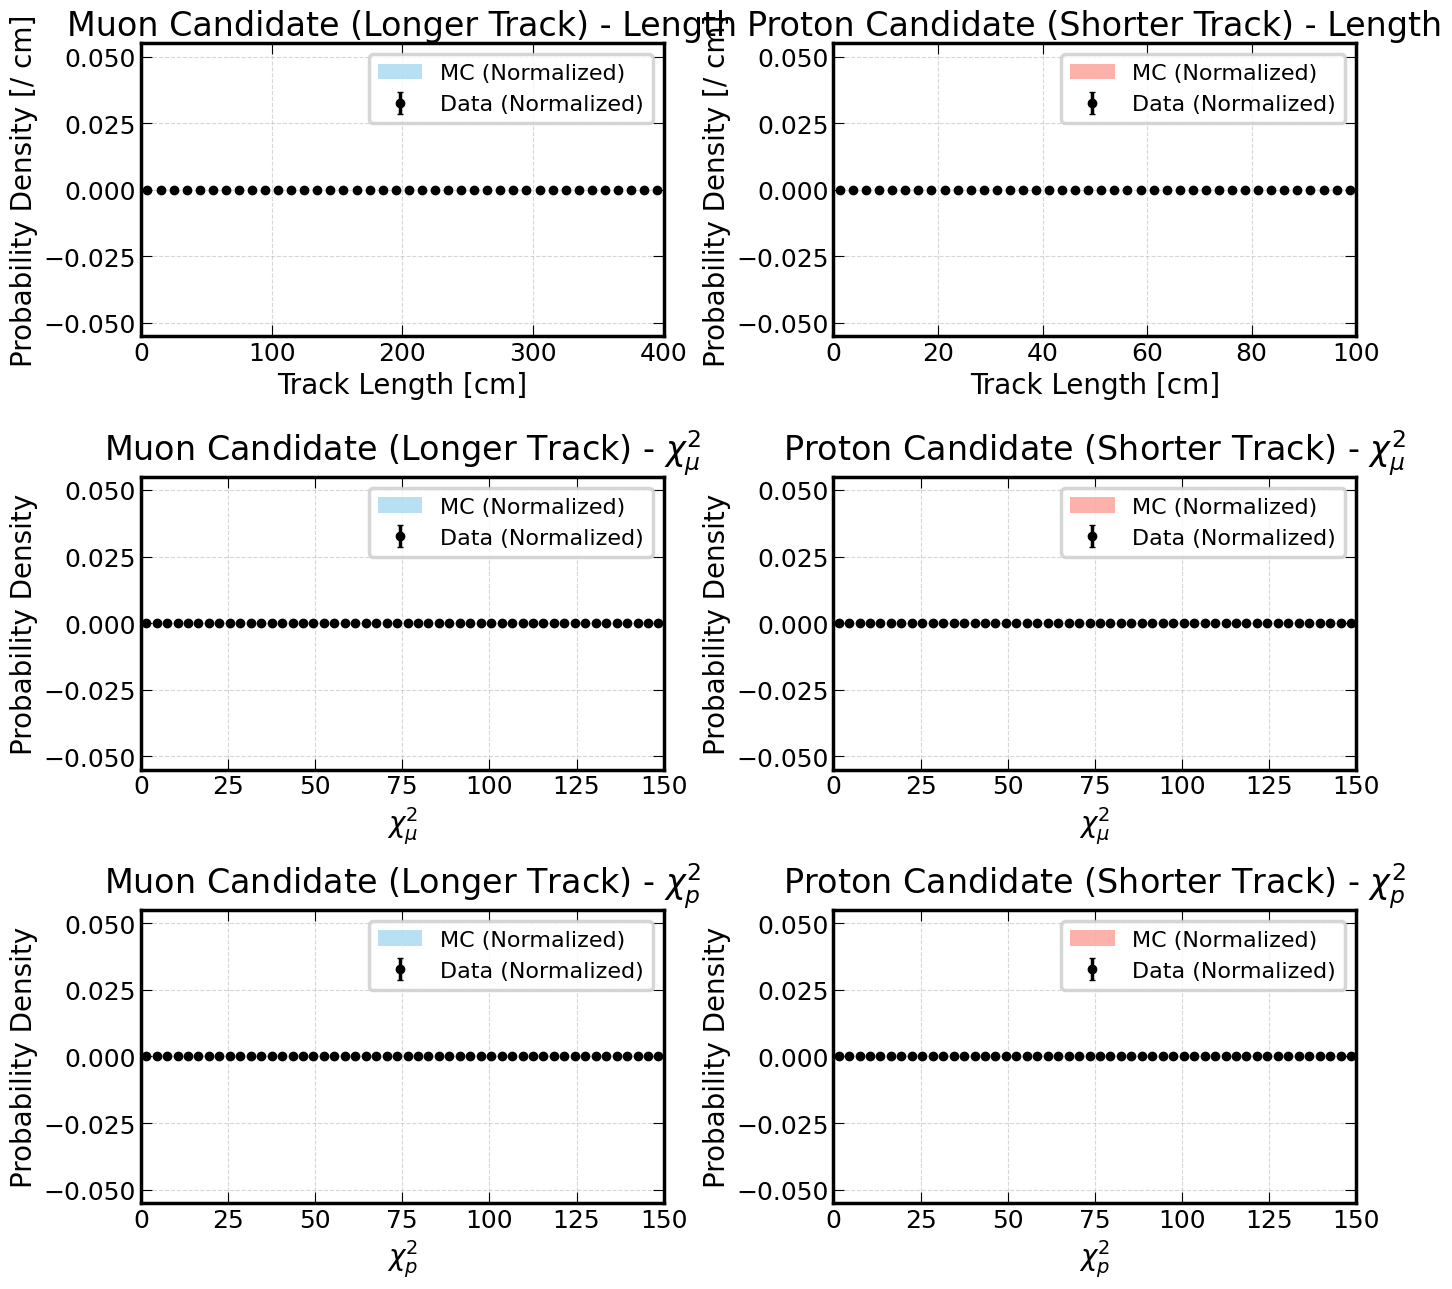

In [137]:
# --- Plotting Configuration ---
fig, axes = plt.subplots(3, 2, figsize=(14, 13))

bins_len_m = np.linspace(0, 400, 41)
bins_len_p = np.linspace(0, 100, 41)
bins_chi2 = np.linspace(0, 150, 51)

# =========================================================
# ROW 1: Track Length
# =========================================================
# 1. Muon Length
centers, norm_counts, norm_errors = get_norm_data_hist(muon_data_lengths, bins_len_m)
plot_mc_density(axes[0, 0], muon_mc_lengths, bins_len_m, 'skyblue', 'MC (Normalized)')

axes[0, 0].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[0, 0].set_title('Muon Candidate (Longer Track) - Length')
axes[0, 0].set_xlabel('Track Length [cm]')
axes[0, 0].set_ylabel('Probability Density [/ cm]')
axes[0, 0].set_xlim(bins_len_m[0], bins_len_m[-1])
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# 2. Proton Length
centers, norm_counts, norm_errors = get_norm_data_hist(proton_data_lengths, bins_len_p)
plot_mc_density(axes[0, 1], proton_mc_lengths, bins_len_p, 'salmon', 'MC (Normalized)')

axes[0, 1].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[0, 1].set_title('Proton Candidate (Shorter Track) - Length')
axes[0, 1].set_xlabel('Track Length [cm]')
axes[0, 1].set_ylabel('Probability Density [/ cm]')
axes[0, 1].set_xlim(bins_len_p[0], bins_len_p[-1])
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

# =========================================================
# ROW 2: Chi2 Muon (chi2u)
# =========================================================
# 3. Muon chi2u
centers, norm_counts, norm_errors = get_norm_data_hist(data_muon_chi2u, bins_chi2)
plot_mc_density(axes[1, 0], mc_muon_chi2u, bins_chi2, 'skyblue', 'MC (Normalized)')
axes[1, 0].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[1, 0].set_title('Muon Candidate (Longer Track) - $\chi^2_{\mu}$')
axes[1, 0].set_xlabel('$\chi^2_{\mu}$')
axes[1, 0].set_ylabel('Probability Density')
axes[1, 0].set_xlim(bins_chi2[0], bins_chi2[-1])
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. Proton chi2u
centers, norm_counts, norm_errors = get_norm_data_hist(data_proton_chi2u, bins_chi2)
plot_mc_density(axes[1, 1], mc_proton_chi2u, bins_chi2, 'salmon', 'MC (Normalized)')
axes[1, 1].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[1, 1].set_title('Proton Candidate (Shorter Track) - $\chi^2_{\mu}$')
axes[1, 1].set_xlabel('$\chi^2_{\mu}$')
axes[1, 1].set_ylabel('Probability Density')
axes[1, 1].set_xlim(bins_chi2[0], bins_chi2[-1])
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# =========================================================
# ROW 3: Chi2 Proton (chi2p)
# =========================================================
# 5. Muon chi2p
centers, norm_counts, norm_errors = get_norm_data_hist(data_muon_chi2p, bins_chi2)
plot_mc_density(axes[2, 0], mc_muon_chi2p, bins_chi2, 'skyblue', 'MC (Normalized)')
axes[2, 0].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[2, 0].set_title('Muon Candidate (Longer Track) - $\chi^2_{p}$')
axes[2, 0].set_xlabel('$\chi^2_{p}$')
axes[2, 0].set_ylabel('Probability Density')
axes[2, 0].set_xlim(bins_chi2[0], bins_chi2[-1])
axes[2, 0].legend()
axes[2, 0].grid(True, linestyle='--', alpha=0.5)

# 6. Proton chi2p
centers, norm_counts, norm_errors = get_norm_data_hist(data_proton_chi2p, bins_chi2)
plot_mc_density(axes[2, 1], mc_proton_chi2p, bins_chi2, 'salmon', 'MC (Normalized)')
axes[2, 1].errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data (Normalized)', capsize=2)
axes[2, 1].set_title('Proton Candidate (Shorter Track) - $\chi^2_{p}$')
axes[2, 1].set_xlabel('$\chi^2_{p}$')
axes[2, 1].set_ylabel('Probability Density')
axes[2, 1].set_xlim(bins_chi2[0], bins_chi2[-1])
axes[2, 1].legend()
axes[2, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [138]:
##############################
# EXPECTED dE/dx FILES
##############################
larsoft_data_v = "v1_02_02"
datadir = "/cvmfs/larsoft.opensciencegrid.org/products/larsoft_data/" + larsoft_data_v + "/ParticleIdentification/"
fhist = datadir + "dEdxrestemplates.root"

profp = uproot.open(fhist)["dedx_range_pro"]
profmu = uproot.open(fhist)["dedx_range_mu"]

proton_dedx = profp.values()
proton_rr = profp.axis().edges()
proton_yerr = profp.errors(error_mode="s")
for i in range(len(proton_yerr)):
    if proton_yerr[i] < 1e-6:
        proton_yerr[i] = (proton_yerr[i-1] + proton_yerr[i+1]) / 2
    if proton_dedx[i] < 1e-6:
        proton_dedx[i] = (proton_dedx[i-1] + proton_dedx[i+1]) / 2

muon_dedx = profmu.values()
muon_rr = profmu.axis().edges()
muon_rr_center = profmu.axis().centers()
muon_yerr = profmu.errors(error_mode="s")

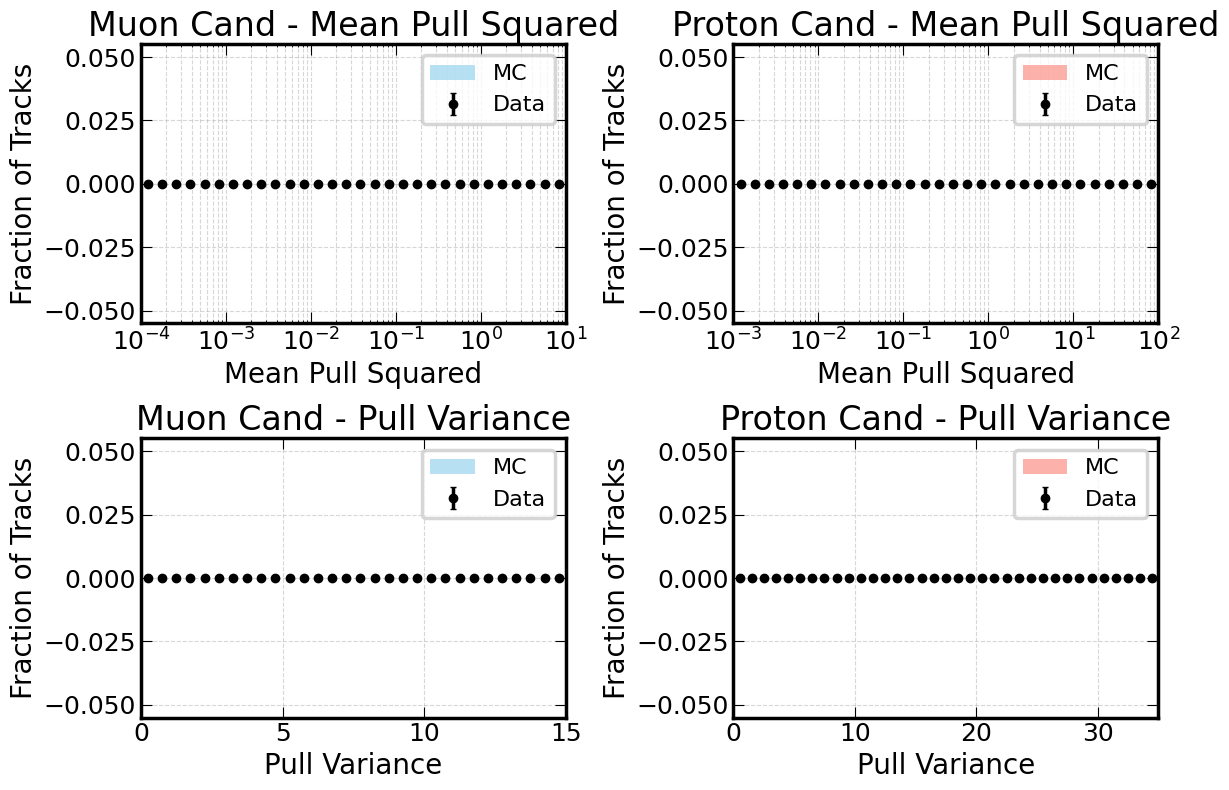

In [139]:
# Helper to get fraction-normalized counts for linear bins (counts / total)
def get_norm_data_hist_lin(data_series, bins):
    in_range = data_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    counts, edges = np.histogram(in_range, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    total = len(in_range)
    
    if total == 0:
        return centers, np.zeros_like(counts), np.zeros_like(counts)
        
    norm_counts = counts / total
    norm_errors = np.sqrt(counts) / total
    return centers, norm_counts, norm_errors
    
def plot_mc_frac(ax, mc_series, bins, color, label):
    in_range = mc_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    counts, edges = np.histogram(in_range, bins=bins)
    total = len(in_range)
    
    if total > 0:
        weights = np.ones_like(in_range) / total
    else:
        weights = None
        
    ax.hist(in_range, bins=bins, weights=weights,
            histtype='stepfilled', color=color, alpha=0.6, label=label)
def get_norm_data_hist_frac(data_series, bins):
    in_range = data_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    counts, edges = np.histogram(in_range, bins=bins)
    centers = np.sqrt(edges[:-1] * edges[1:])  # Geometric mean for log placement
    total = len(in_range)
    
    if total == 0:
        return centers, np.zeros_like(counts), np.zeros_like(counts)
        
    norm_counts = counts / total
    norm_errors = np.sqrt(counts) / total
    return centers, norm_counts, norm_errors
    
# Helper to plot MC stepfilled histogram for linear bins (counts / total)
def plot_mc_lin(ax, mc_series, bins, color, label):
    in_range = mc_series.dropna()
    in_range = in_range[(in_range >= bins[0]) & (in_range <= bins[-1])]
    
    counts, edges = np.histogram(in_range, bins=bins)
    total = len(in_range)
    
    weights = np.ones_like(in_range) / total if total > 0 else None
    ax.hist(in_range, bins=bins, weights=weights,
            histtype='stepfilled', color=color, alpha=0.6, label=label)

# Function to compute track-level mean pull (p_bar) and variance (var_p)
def compute_track_p_stats(hits_df, exprr, expdedx, experr, dedxname="dedx"):
    dedx_exp = pd.cut(hits_df.rr, exprr, labels=expdedx).astype(float)
    dedx_err = pd.cut(hits_df.rr, exprr, labels=experr).astype(float)
    dedx_res = (0.04231 + 0.0001783 * hits_df[dedxname]**2) * hits_df[dedxname]

    p_i = (hits_df[dedxname] - dedx_exp) / np.sqrt(dedx_err**2 + dedx_res**2)

    when_valid = (hits_df.rr < 26.0) & ~hits_df.firsthit & ~hits_df.lasthit & (hits_df[dedxname] < 1000.0)
    
    track_levels = list(range(hits_df.index.nlevels - 1))
    p_valid = p_i[when_valid].groupby(level=track_levels)

    p_bar = p_valid.mean()
    p_var = p_valid.var(ddof=0)
    return p_bar, p_var

# Setup 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Define particle-specific binning matching the provided plots
# Row 0: Mean pull squared ^2 (log scale)
bins_pbar2_muon = np.logspace(-4, 1, 31)    # 10^-4 to 10^1
bins_pbar2_proton = np.logspace(-3, 2, 31)  # 10^-3 to 10^2

# Row 1: Var(pull) (linear scale)
bins_pvar_muon = np.linspace(0, 15, 31)     # 0 to 15
bins_pvar_proton = np.linspace(0, 35, 36)   # 0 to 35

candidates = [
    ("Muon Cand", muon_rr, muon_dedx, muon_yerr, mc_muon_hits, data_muon_hits, bins_pbar2_muon, bins_pvar_muon, "skyblue"),
    ("Proton Cand", proton_rr, proton_dedx, proton_yerr, mc_proton_hits, data_proton_hits, bins_pbar2_proton, bins_pvar_proton, "salmon")
]

for col, (cand_label, exprr, expdedx, experr, mc_hits, data_hits, bins_pbar2, bins_pvar, color) in enumerate(candidates):
    
    mc_pbar, mc_pvar = compute_track_p_stats(mc_hits, exprr, expdedx, experr)
    data_pbar, data_pvar = compute_track_p_stats(data_hits, exprr, expdedx, experr)
    
    # Square the mean pull ^2
    mc_pbar2 = mc_pbar**2
    data_pbar2 = data_pbar**2

    # --- Row 0: Mean Pull Squared ^2 (Log Scale) ---
    ax_top = axes[0, col]
    centers, norm_counts, norm_errors = get_norm_data_hist_frac(data_pbar2, bins_pbar2)
    plot_mc_frac(ax_top, mc_pbar2, bins_pbar2, color, 'MC')
    ax_top.errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data', capsize=2)
    
    ax_top.set_xscale('log')
    ax_top.set_title(f"{cand_label} - Mean Pull Squared")
    ax_top.set_xlabel("Mean Pull Squared")
    ax_top.set_ylabel("Fraction of Tracks")
    ax_top.set_xlim(bins_pbar2[0], bins_pbar2[-1])
    ax_top.legend()
    ax_top.grid(True, which="both", linestyle='--', alpha=0.5)

    # --- Row 1: Var(pull) (Linear Scale) ---
    ax_bot = axes[1, col]
    centers, norm_counts, norm_errors = get_norm_data_hist_lin(data_pvar, bins_pvar)
    plot_mc_lin(ax_bot, mc_pvar, bins_pvar, color, 'MC')
    ax_bot.errorbar(centers, norm_counts, yerr=norm_errors, fmt='ko', label='Data', capsize=2)
    
    ax_bot.set_title(f"{cand_label} - Pull Variance")
    ax_bot.set_xlabel("Pull Variance")
    ax_bot.set_ylabel("Fraction of Tracks")
    ax_bot.set_xlim(bins_pvar[0], bins_pvar[-1])
    ax_bot.legend()
    ax_bot.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

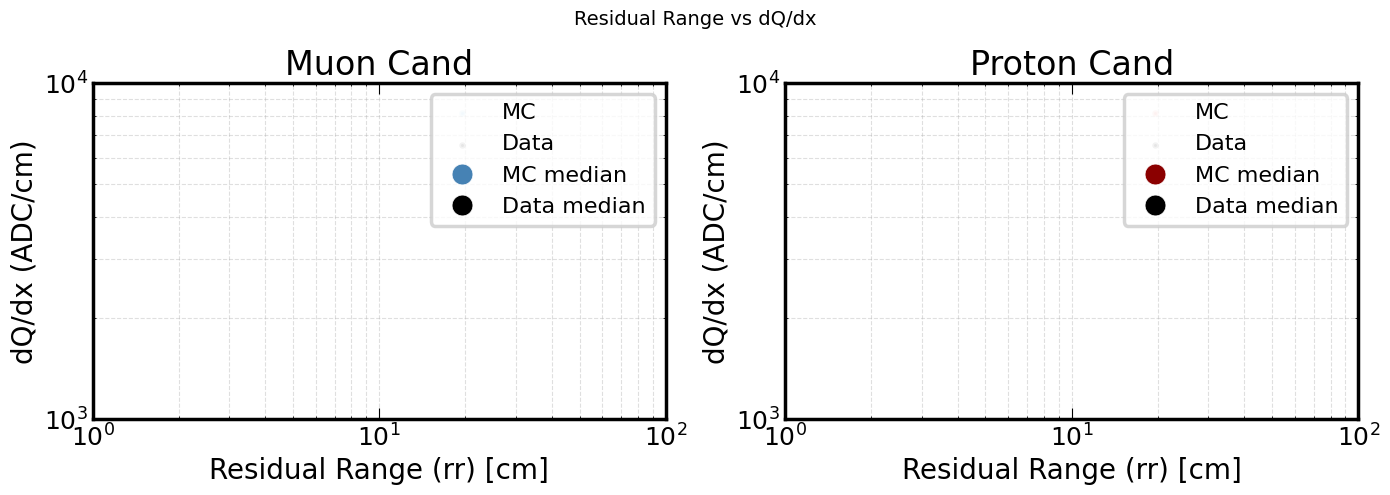

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

MAX_HITS = 500_000
N_BINS = 20

XLIM = (1e0, 1e2)
YLIM = (1e3, 1e4)

datasets = [
    ("Muon Cand",   mc_muon_hits,    data_muon_hits,   "skyblue",  "steelblue", axes[0]),
    ("Proton Cand", mc_proton_hits,  data_proton_hits, "salmon",   "darkred",   axes[1]),
]

def apply_axis_cuts(df, xlim, ylim):
    return df[
        (df["rr"]   >= xlim[0]) & (df["rr"]   <= xlim[1]) &
        (df["dqdx"] >= ylim[0]) & (df["dqdx"] <= ylim[1]) &
        (df["pitch"] >= 0.3)    & (df["pitch"] <= 0.75)
    ]

for label, mc_df, data_df, color, dark_color, ax in datasets:
    mc_cut   = apply_axis_cuts(mc_df,   XLIM, YLIM)
    data_cut = apply_axis_cuts(data_df, XLIM, YLIM)

    mc_plot   = mc_cut.sample(min(MAX_HITS, len(mc_cut)),     random_state=42)
    data_plot = data_cut.sample(min(MAX_HITS, len(data_cut)), random_state=42)

    ax.scatter(
        mc_plot["rr"], mc_plot["dqdx"],
        s=0.5, alpha=0.05, color=color, rasterized=True, label="MC"
    )
    ax.scatter(
        data_plot["rr"], data_plot["dqdx"],
        s=0.5, alpha=0.05, color="black", rasterized=True, label="Data"
    )

    # Log-spaced bin edges and centers
    bin_edges   = np.logspace(0, 2, N_BINS + 1)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    # Median computed on the plotted subsample, already within axis cuts
    for df, c, lbl in [(mc_plot, dark_color, "MC median"), (data_plot, "black", "Data median")]:
        bin_idx = np.digitize(df["rr"], bin_edges)
        medians = []
        for i in range(1, len(bin_edges)):
            in_bin = df.loc[bin_idx == i, "dqdx"]
            medians.append(in_bin.median() if len(in_bin) > 0 else np.nan)

        ax.plot(
            bin_centers, medians,
            "o", color=c, markersize=5, zorder=5,
            markeredgecolor="white", markeredgewidth=0.5, label=lbl
        )

    ax.set_title(label)
    ax.set_xlabel("Residual Range (rr) [cm]")
    ax.set_ylabel("dQ/dx (ADC/cm)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)
    ax.legend(markerscale=3)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.suptitle("Residual Range vs dQ/dx", fontsize=14)
plt.tight_layout()
plt.show()